In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import os
#run from repo root...
os.chdir(r"C:/Users/jamed\Documents/repos/terrain_classification_project/TerrainClassificationForFloodModelling")

In [39]:
from structured_data_utils.data import ModelData
from structured_data_utils.structured_data_interfacing import standardise_dataset


In [40]:
standardise_dataset("WILLOWAN", force=True)

Standardised file already exists at data\WILLOWAN\POSITIVE_STANDARDISED.tif. Skipping. Use force=True to override.
Standardised file already exists at data\WILLOWAN\COMBINED_STANDARDISED.tif. Skipping. Use force=True to override.
[local_normalise:input] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5033127 nan%=9.68
[local_normalise:input] min=113.168098 max=128.880936 mean=124.579155 std=1.396130 median=124.953583 p01=118.729362 p05=121.867531 p95=125.641922 p99=125.835381
[local_normalise:output] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5572350 nan%=0.00
[local_normalise:output] min=0.000000 max=48.087933 mean=21.435007 std=1.000000 median=21.435066 p01=18.279329 p05=20.686172 p95=22.154362 p99=24.739069
dwl shapes -- data: torch.Size([1, 2135, 2610]), labels: torch.Size([1, 2135, 2610])
SegmentedDataWithLabels size: data=0.06 GB, labels=0.06 GB, total=0.12 GB
Gross size of all SegmentedDataWithLabels so far: 0.12 GB
SegmentedDataWithLabels size: 

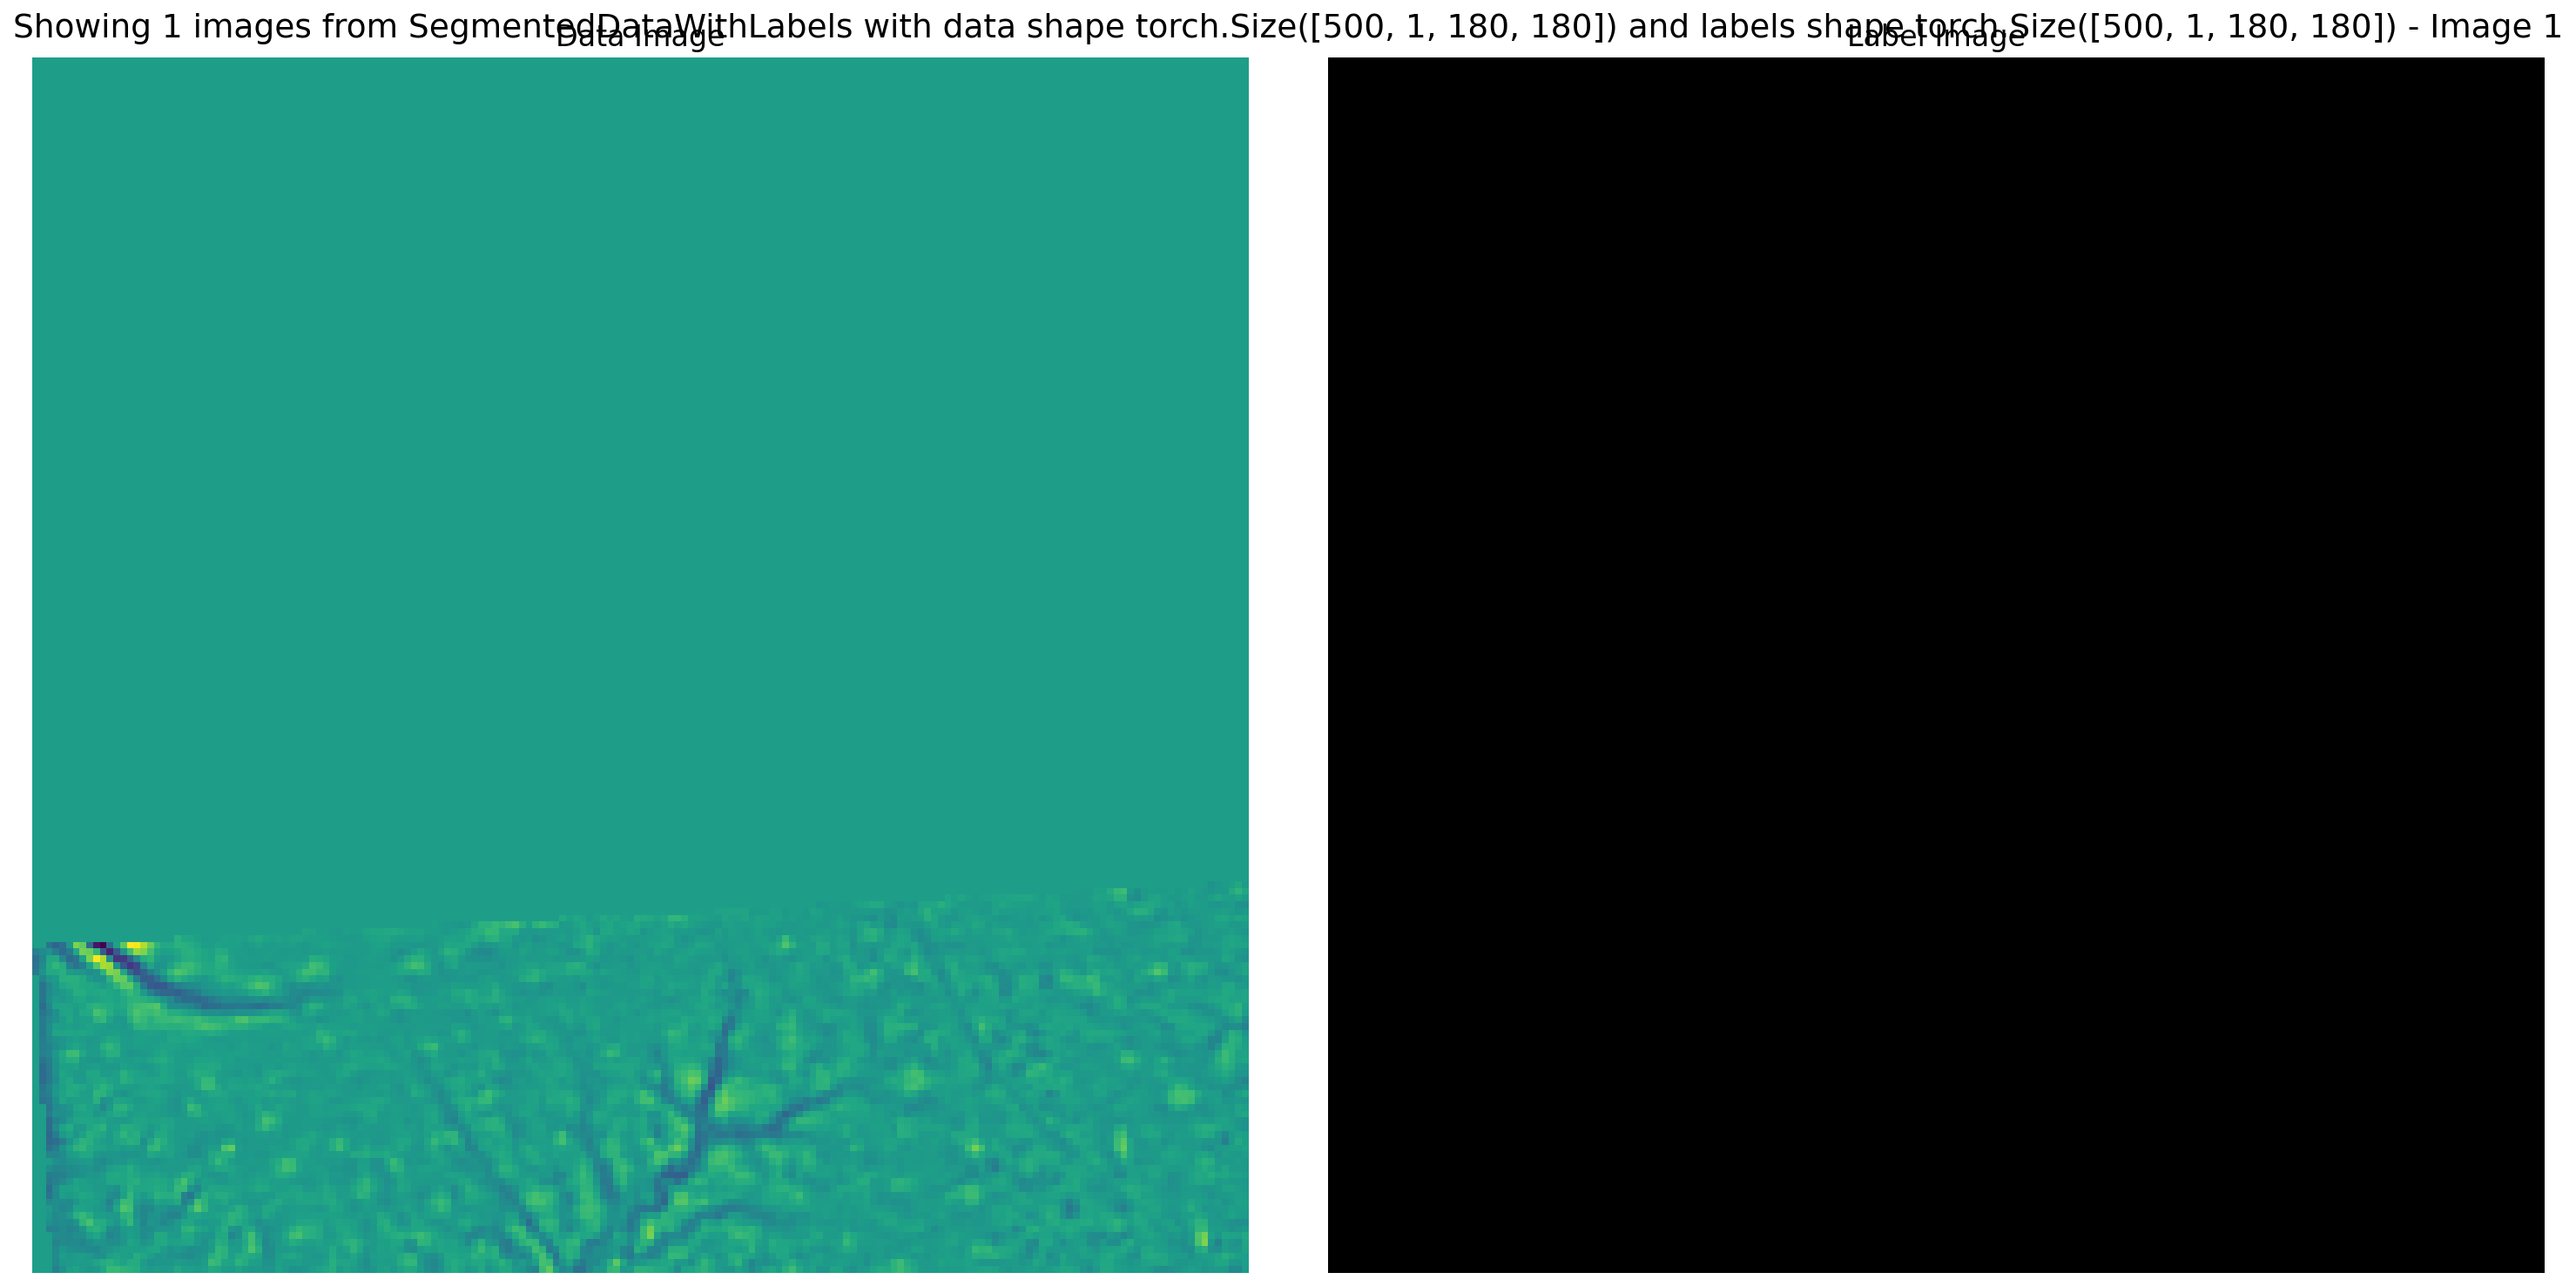

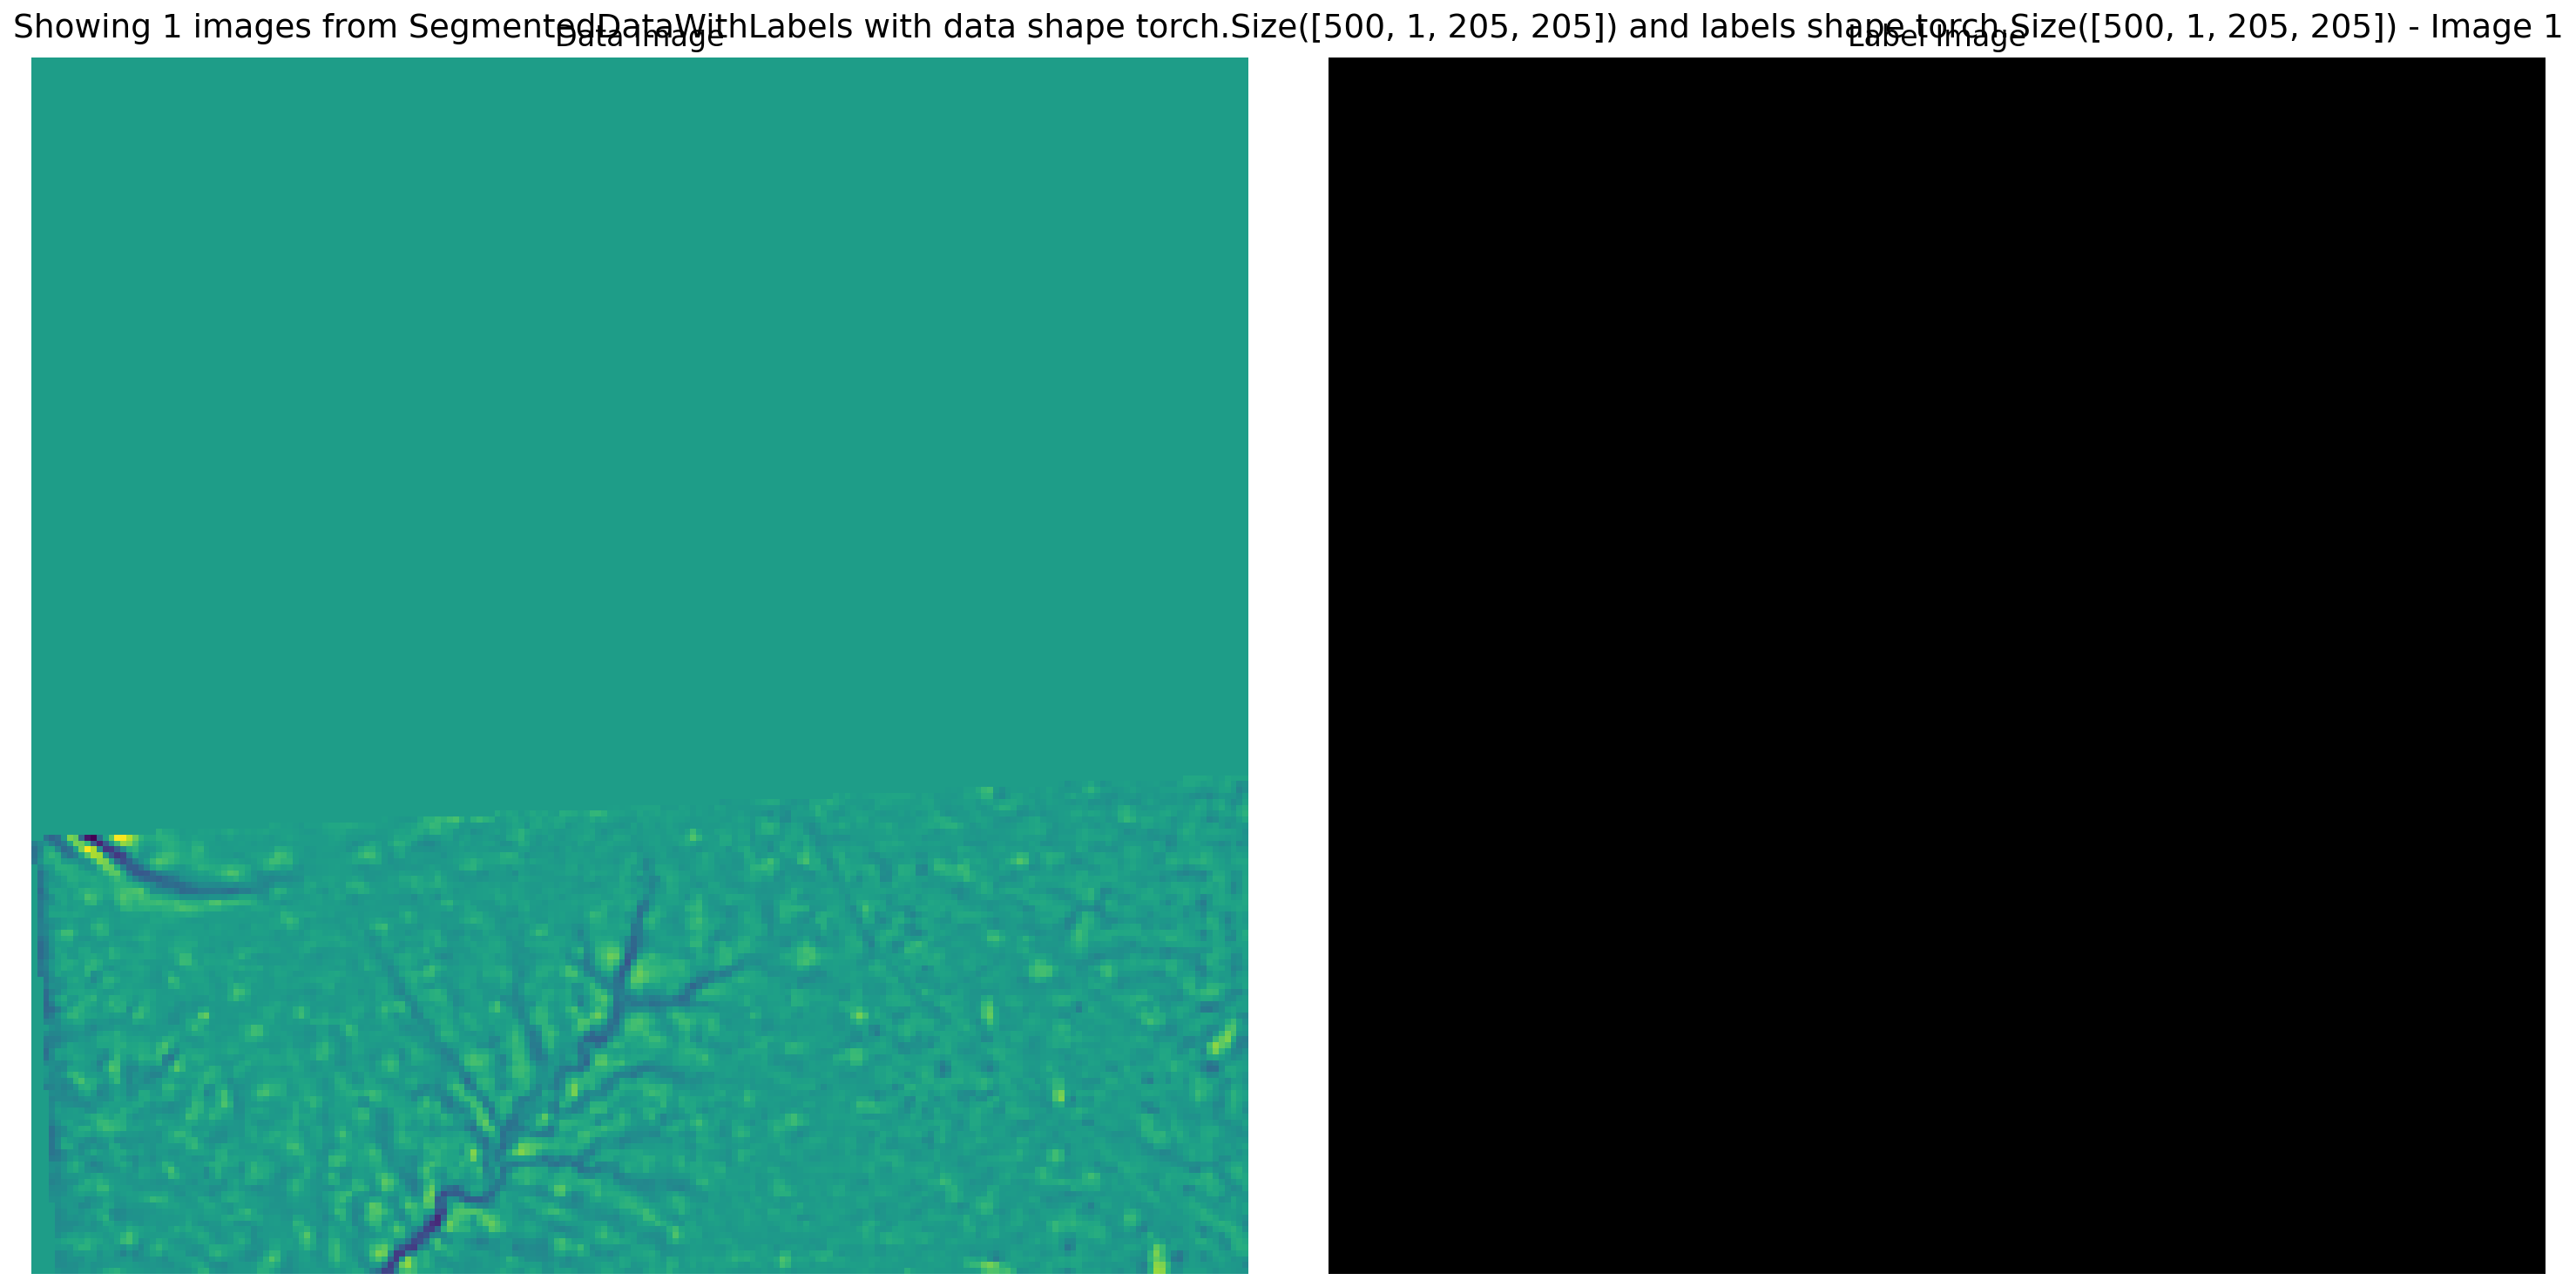

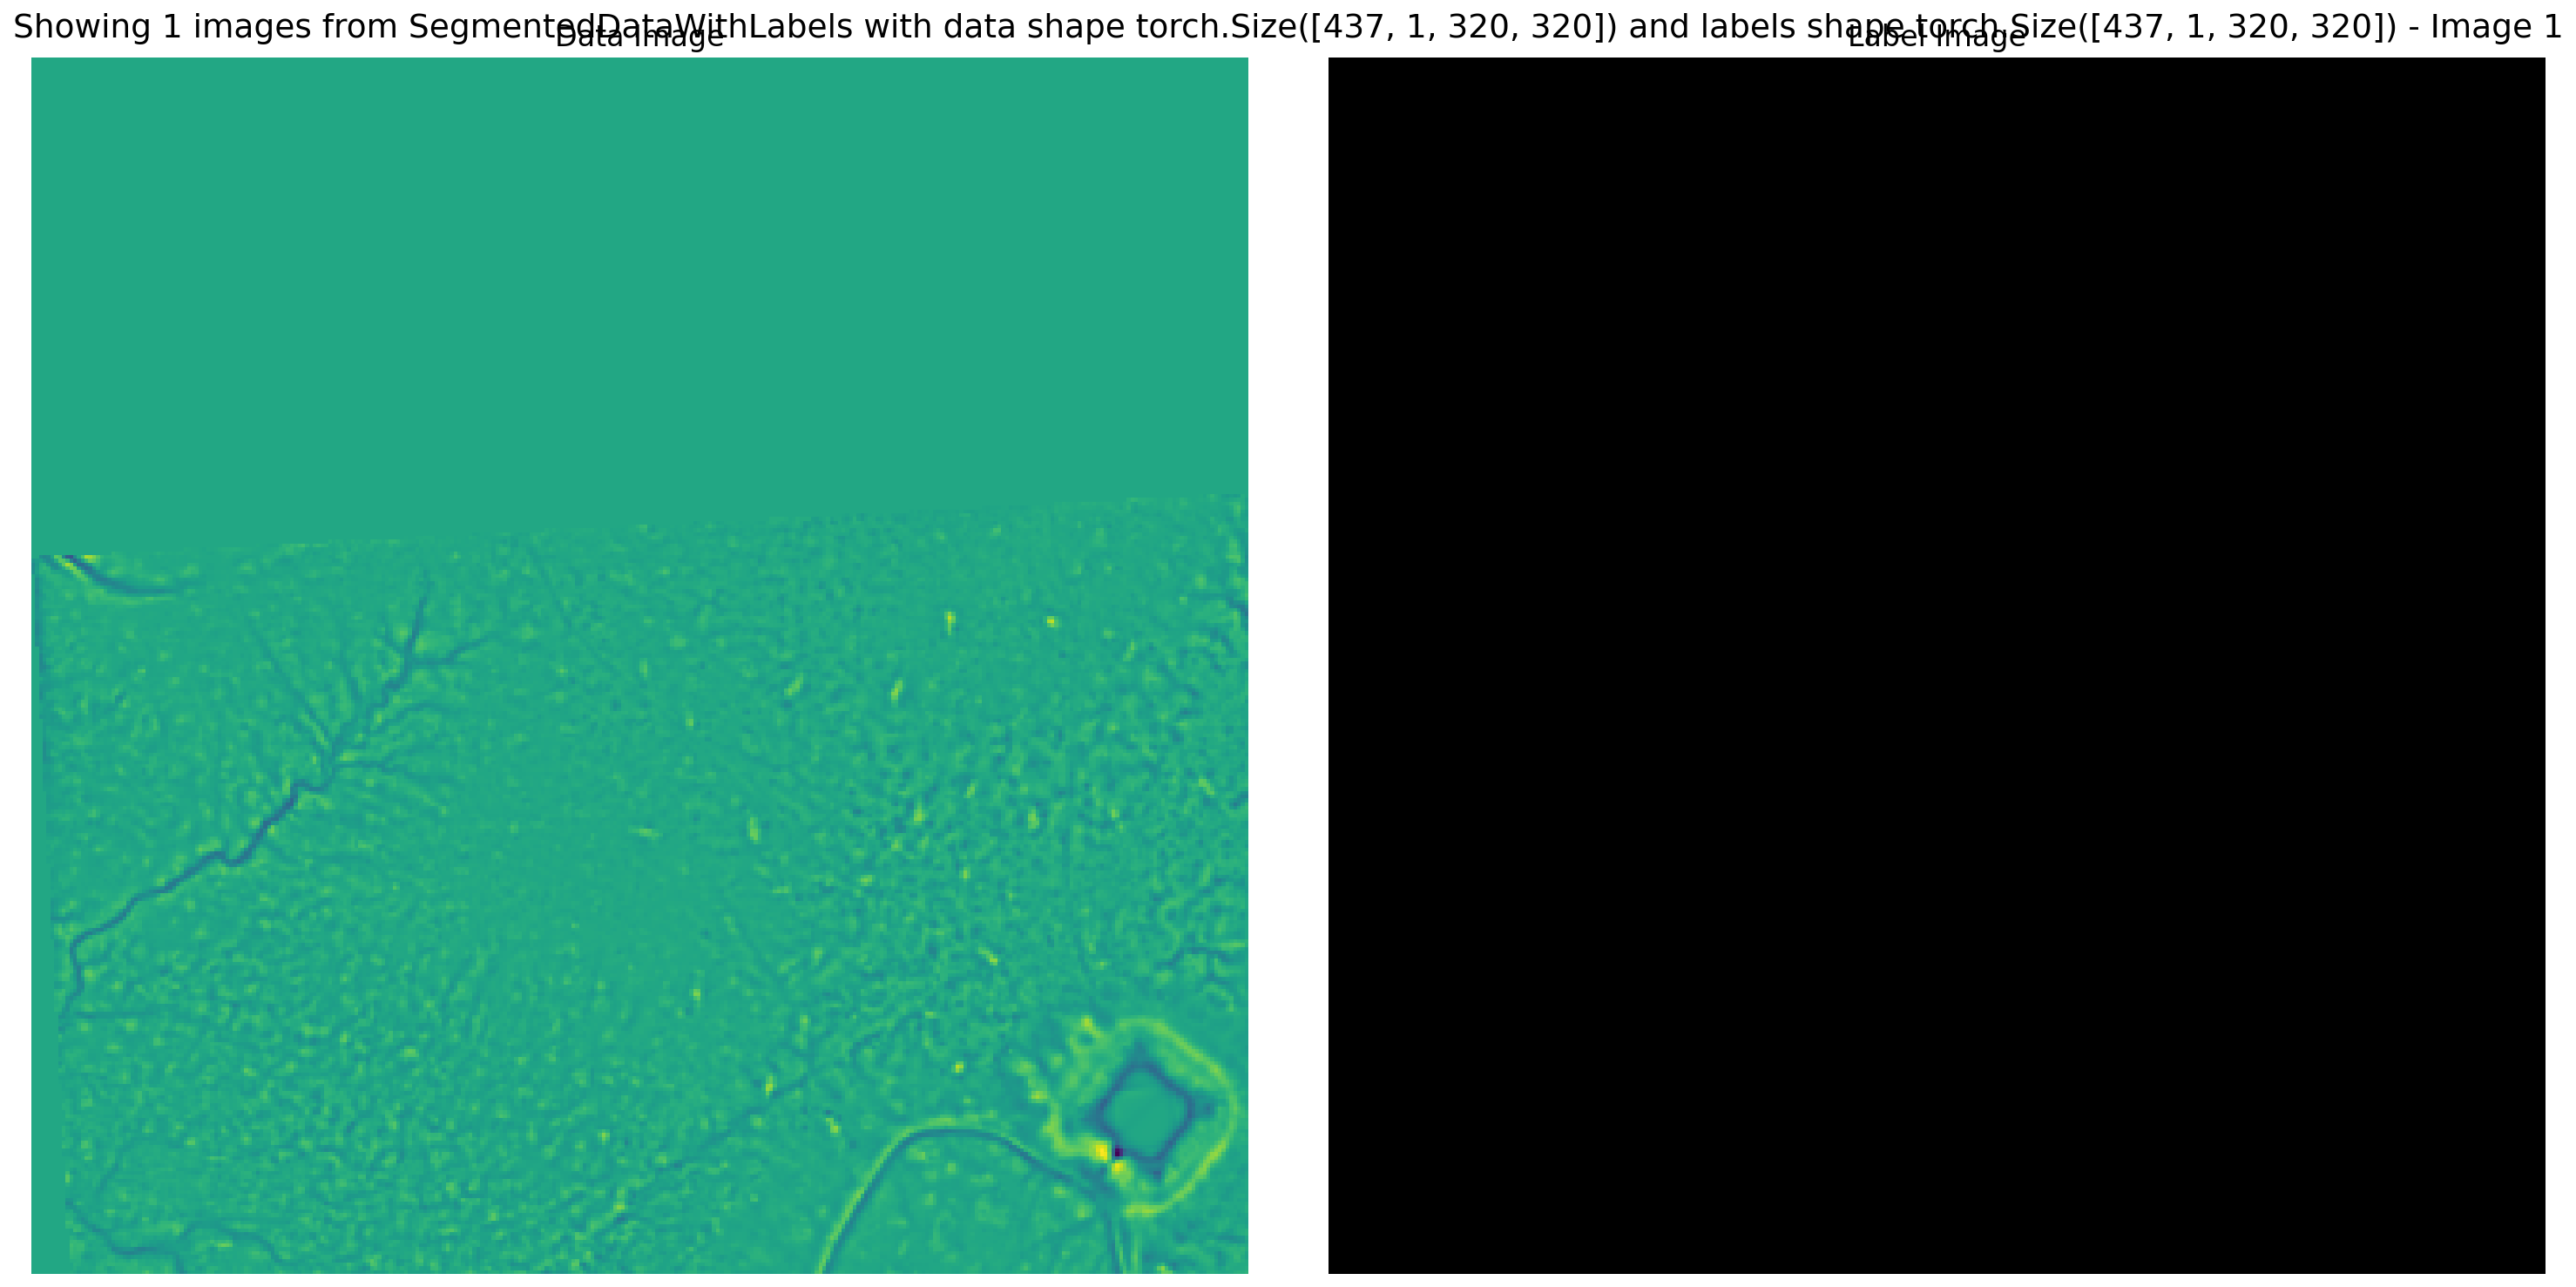

In [42]:
willowan_data = ModelData()
willowan_data.prepare_data("WILLOWAN", sliding_window_size=200, stride=100)

In [ ]:
from model_prototyping.unet_implementation.metrics import show_matrices
show_matrices([willowan_data.segmented_data_with_labels.data[0][0], willowan_data.segmented_data_with_labels.labels[0][0]])

In [ ]:
#standardise_dataset("WILLOWAN", force=True)

In [ ]:
#beermery_data = ModelData()
#beermery_data.prepare_data("BEERMERY", sliding_window_size=300, stride=200)

In [ ]:
from model_prototyping.unet_implementation.metrics import show_matrices
#show_matrices([beermery_data.data_with_labels.data[0], beermery_data.data_with_labels.labels[0]])

In [ ]:
#combined_data = ModelData.splice_model_data([beermery_data, willowan_data])

In [ ]:
from model_prototyping.unet_implementation.modules import train_model, test_model_visual


In [ ]:
from model_prototyping.unet_implementation.constants import (
    UNET_BLOCK_BASELINE,
    UNET_BLOCK_PREACT,
    UNET_BLOCK_DROPOUT,
    UNET_BLOCK_DILATED,
    UNET_BLOCK_RESIDUAL,
)


In [ ]:
willowan_data.data_with_labels.data.shape

In [ ]:
willowan_data.segmented_data_with_labels.data.shape

Epoch 50/1000 - loss: 0.0772
lr: 0.000488126013940816


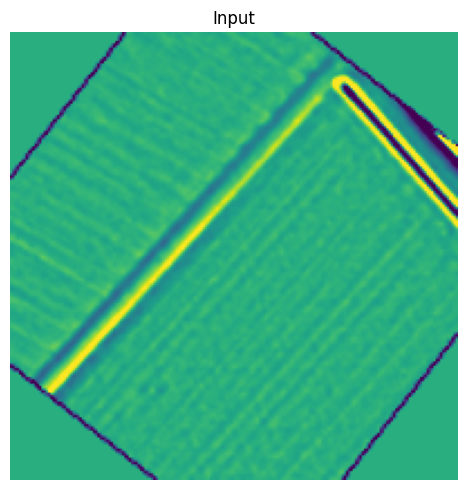

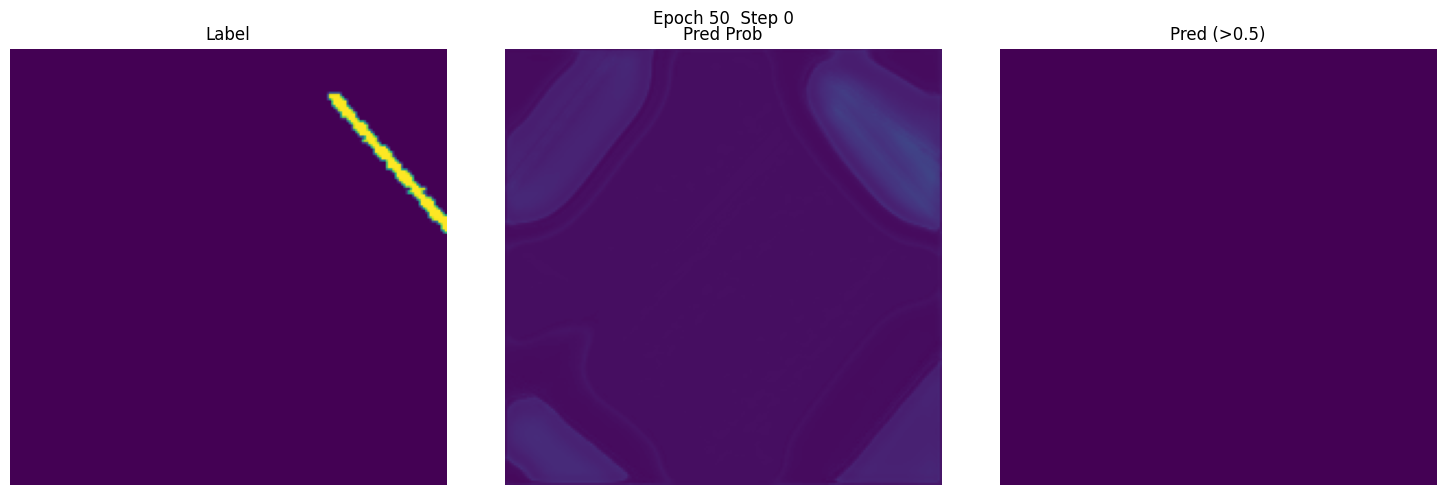

Epoch 100/1000 - loss: 0.0007
lr: 0.00045329747873729034


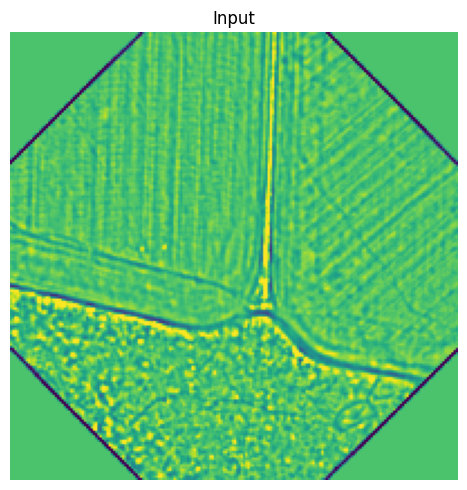

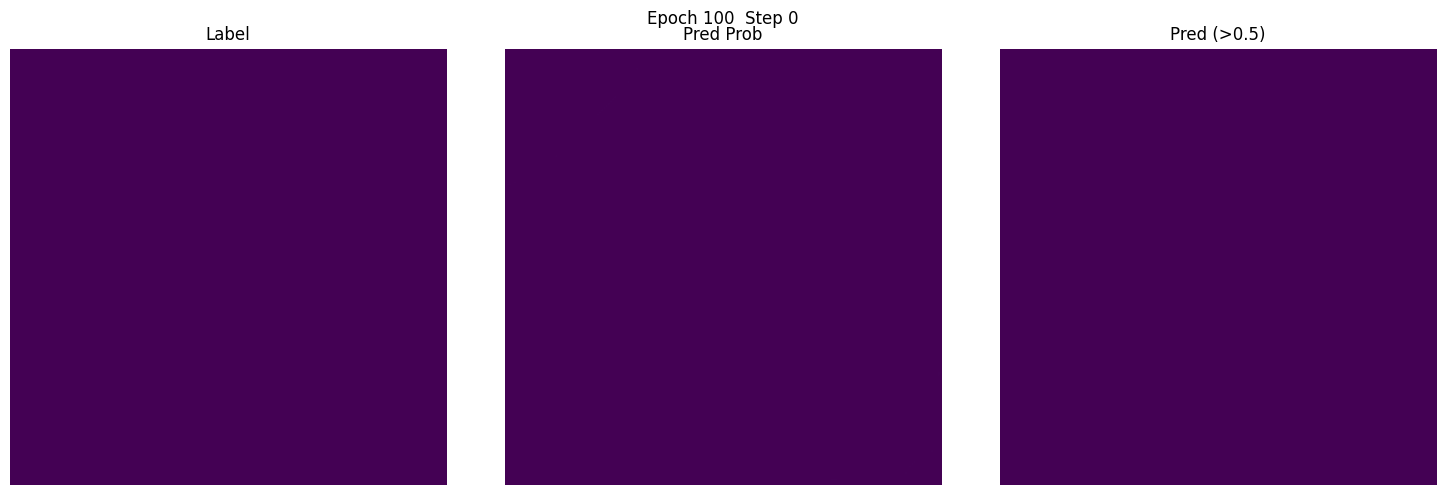

Epoch 150/1000 - loss: 0.0000
lr: 0.0004004238426477074


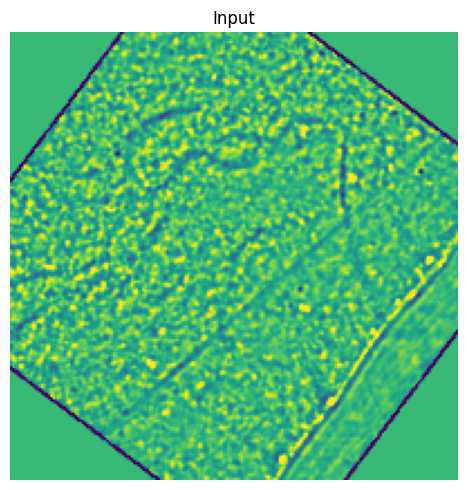

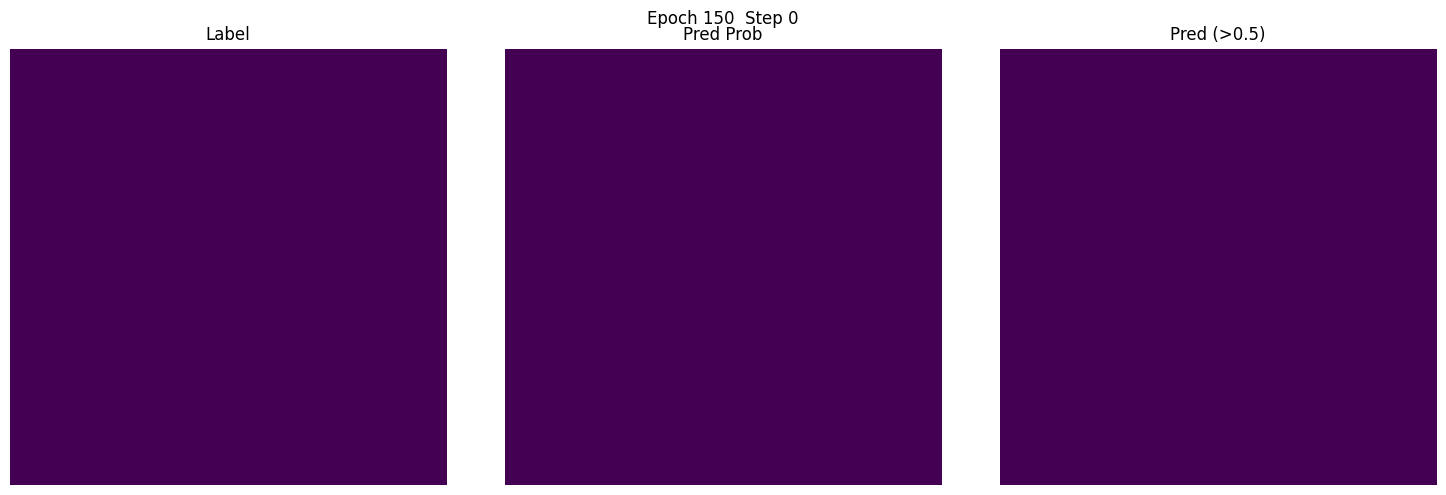

Epoch 200/1000 - loss: 0.0000
lr: 0.00033646649945963847


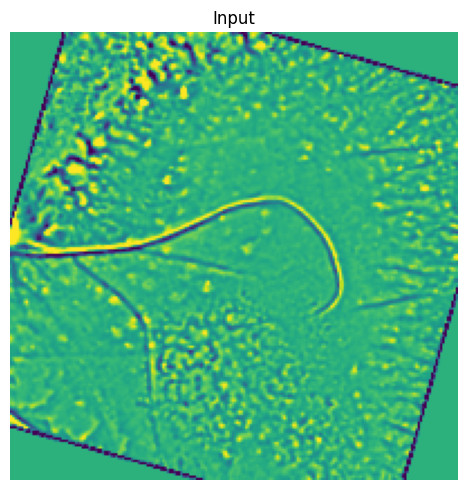

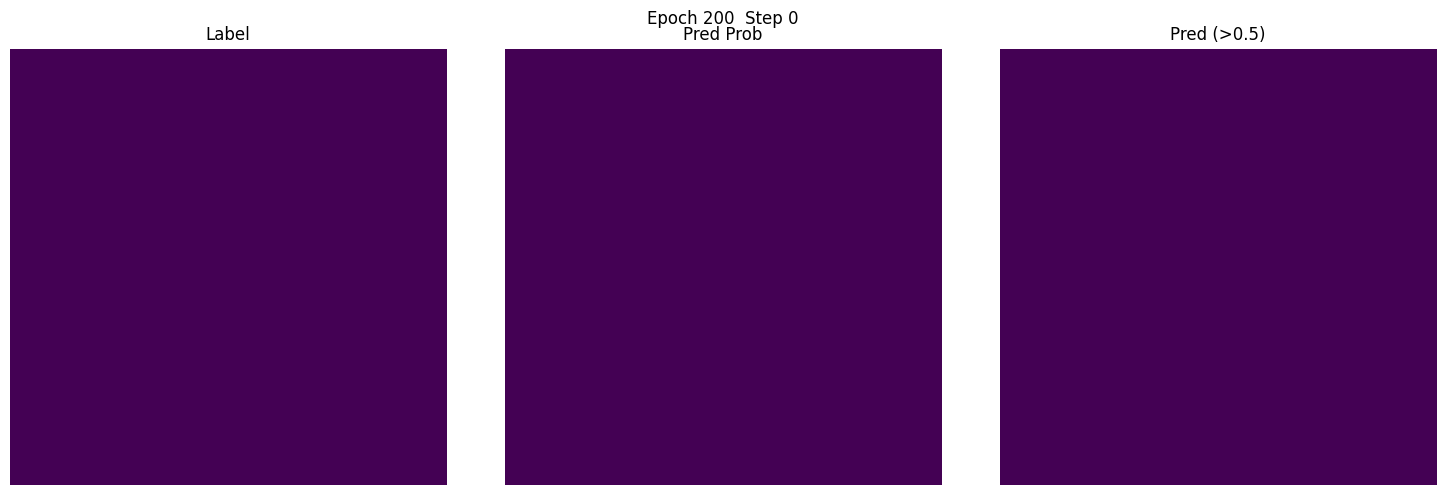

Epoch 250/1000 - loss: 0.5243
lr: 0.000268936040199898


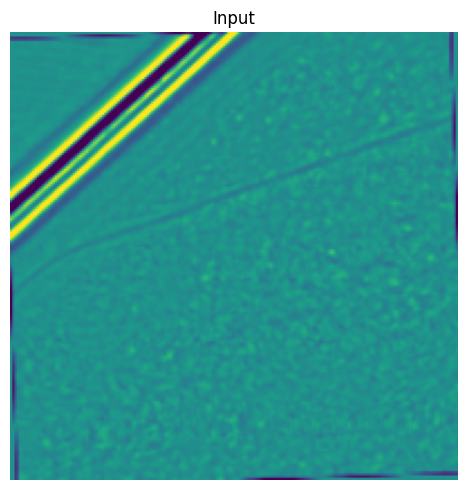

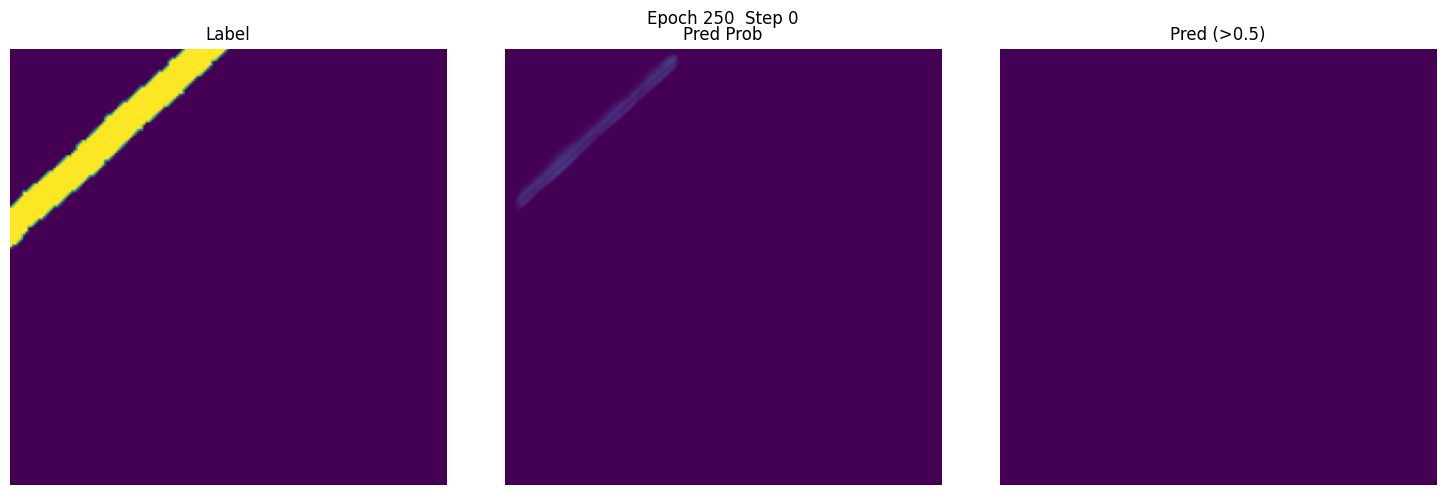

Epoch 300/1000 - loss: 0.1376
lr: 0.00020447558417059194


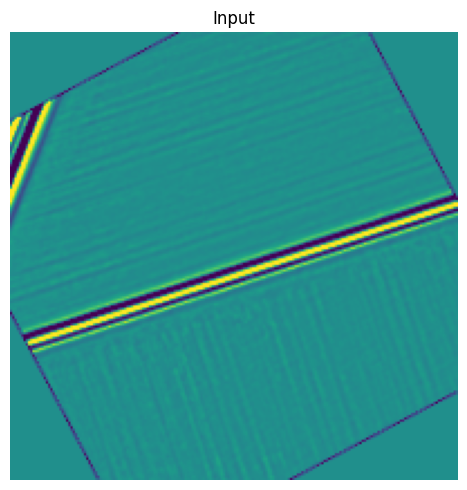

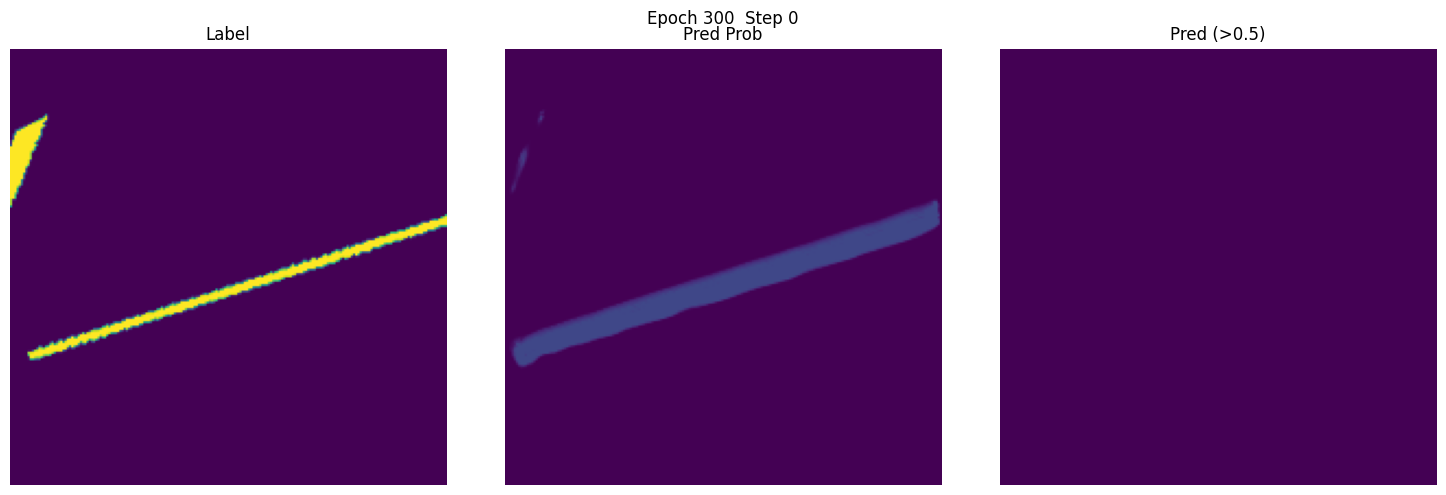

Epoch 350/1000 - loss: 0.0000
lr: 0.00014788331745703477


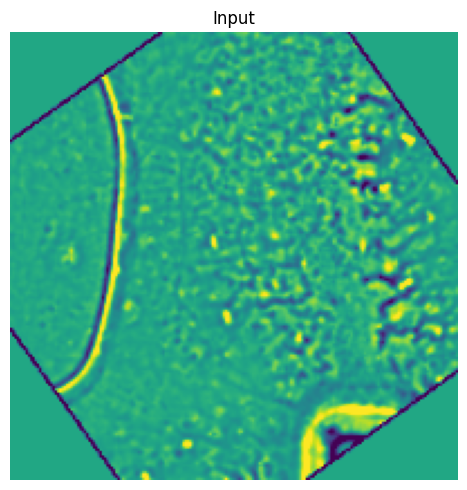

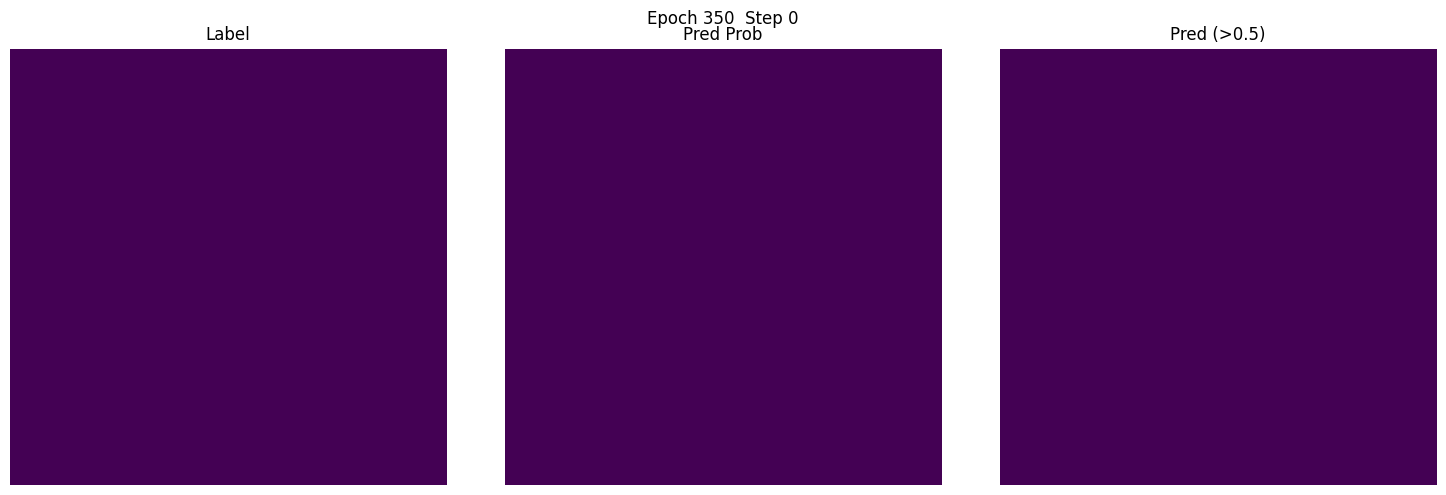

Epoch 400/1000 - loss: 0.0760
lr: 0.00010173776360567818


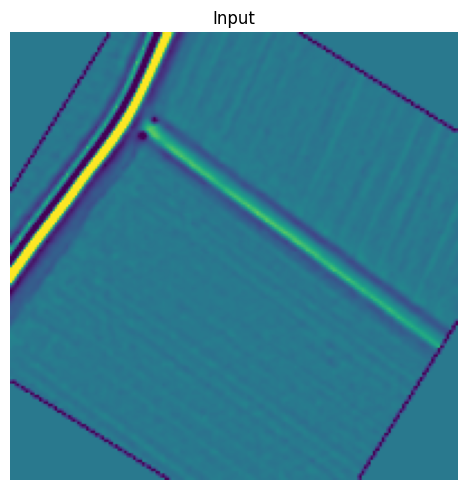

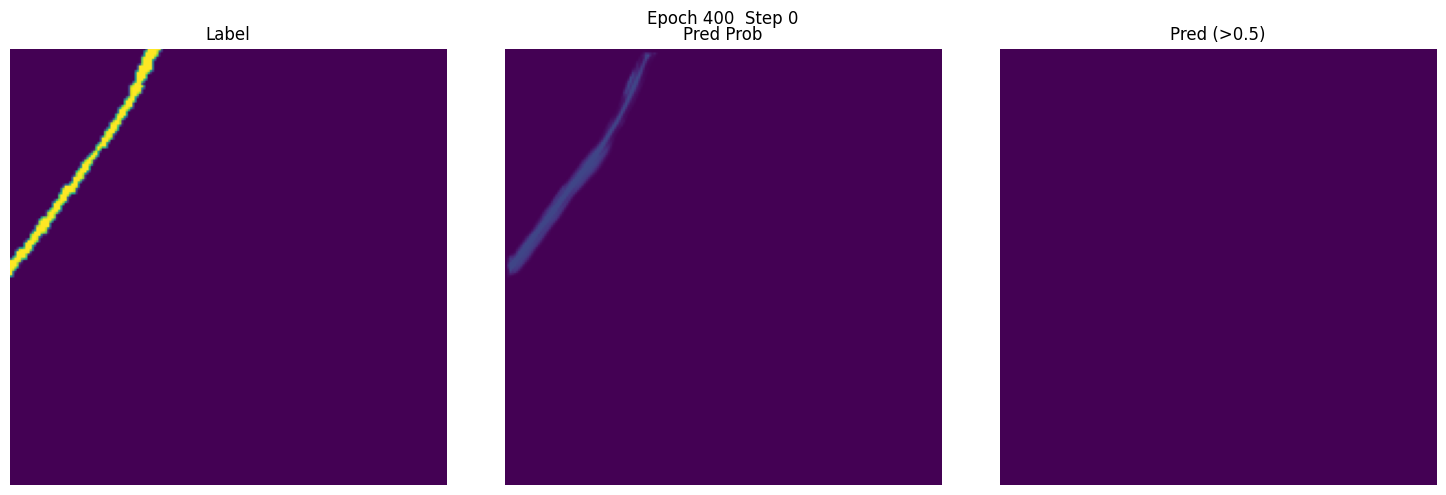

Epoch 450/1000 - loss: 0.0000
lr: 6.657795700355383e-05


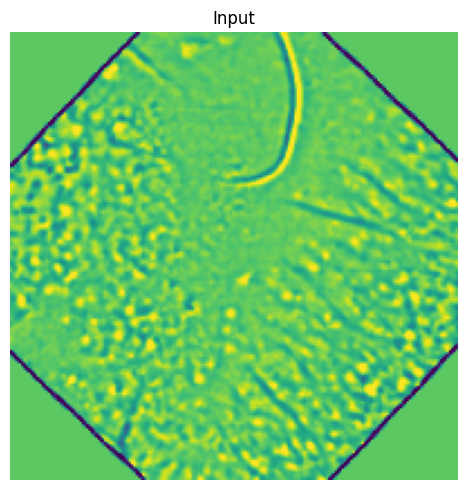

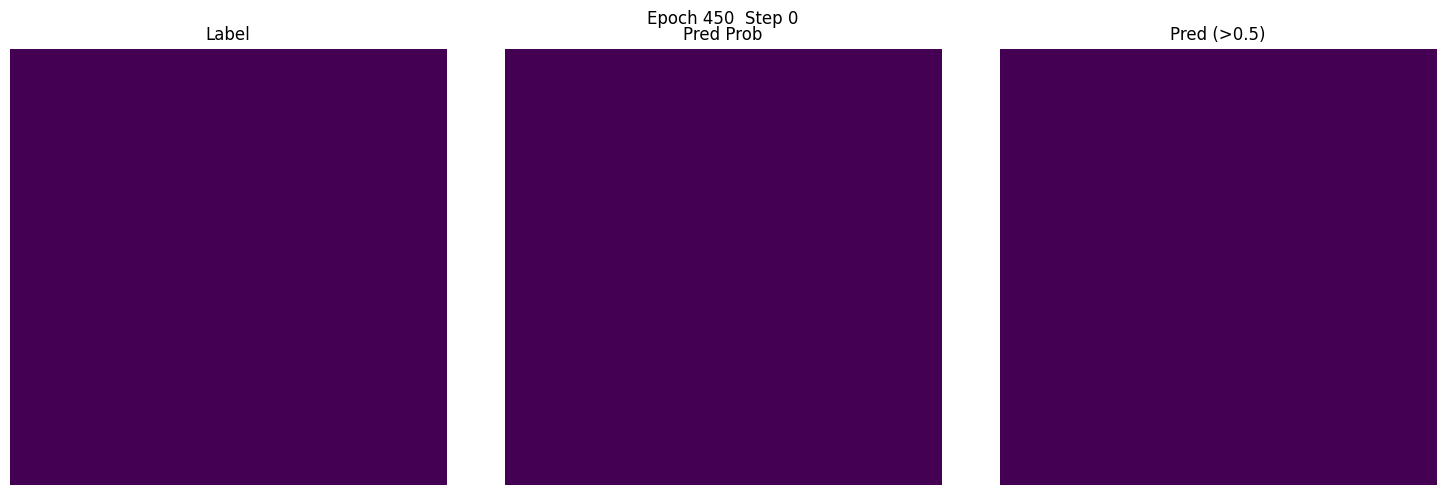

Epoch 500/1000 - loss: 0.1159
lr: 4.144422447466562e-05


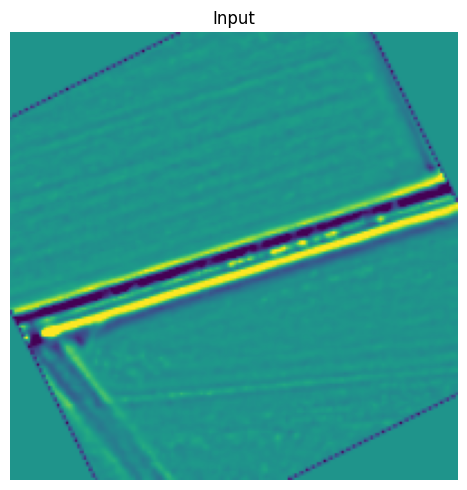

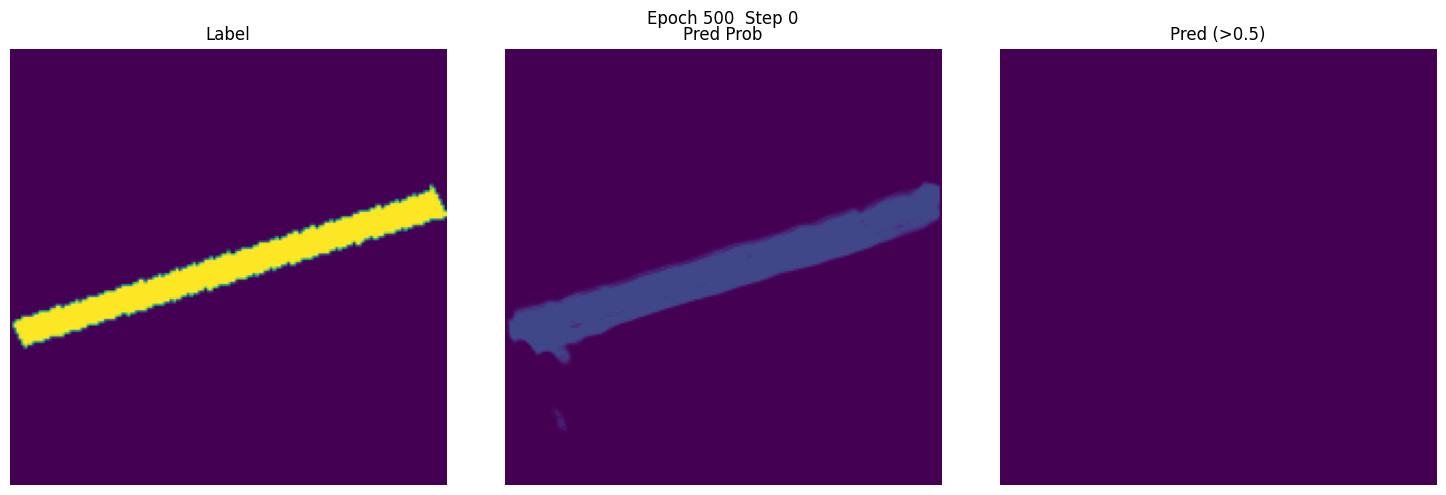

Epoch 550/1000 - loss: 0.0000
lr: 2.4540468277296644e-05


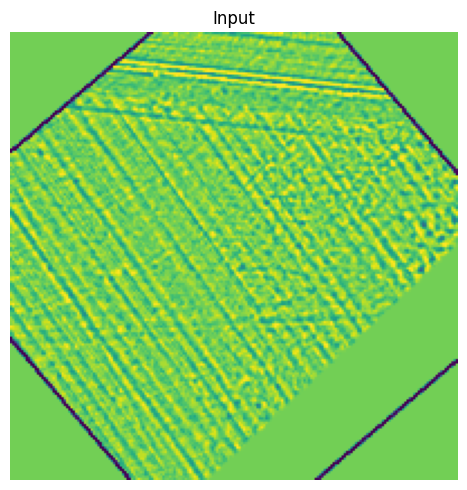

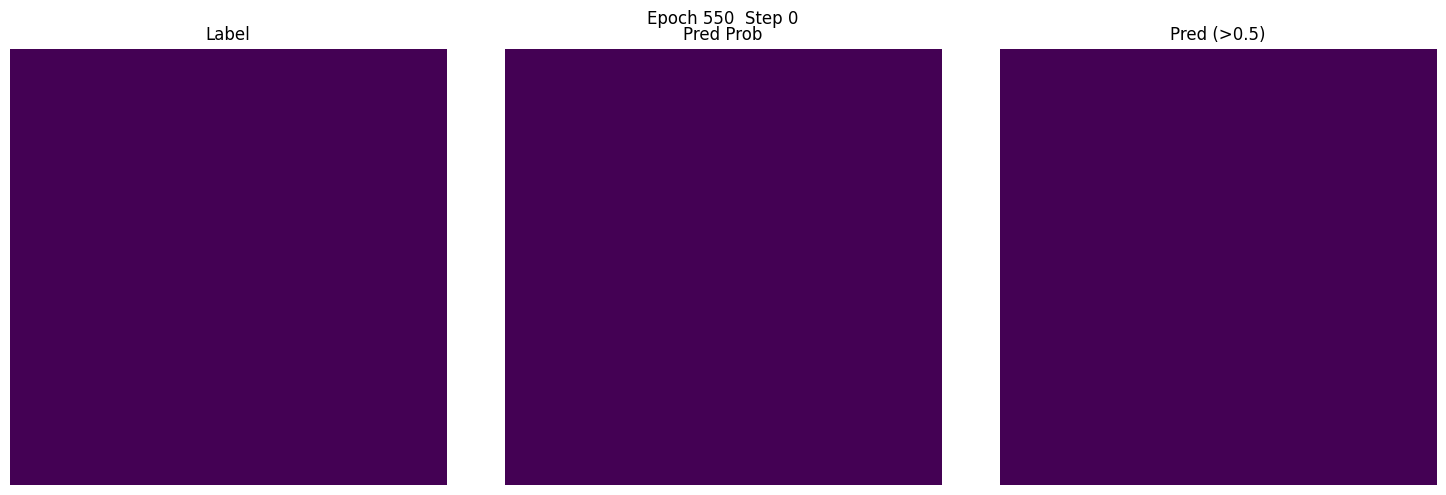

Epoch 600/1000 - loss: 0.0000
lr: 1.3822511160144456e-05


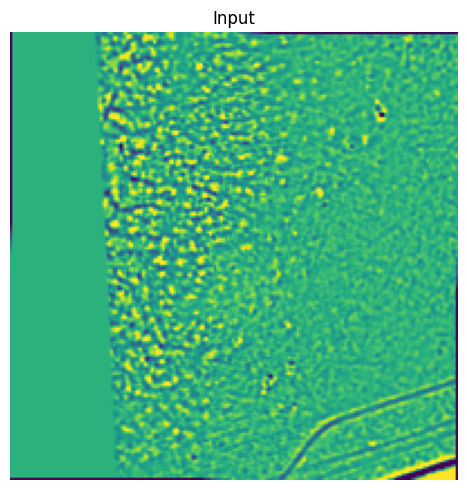

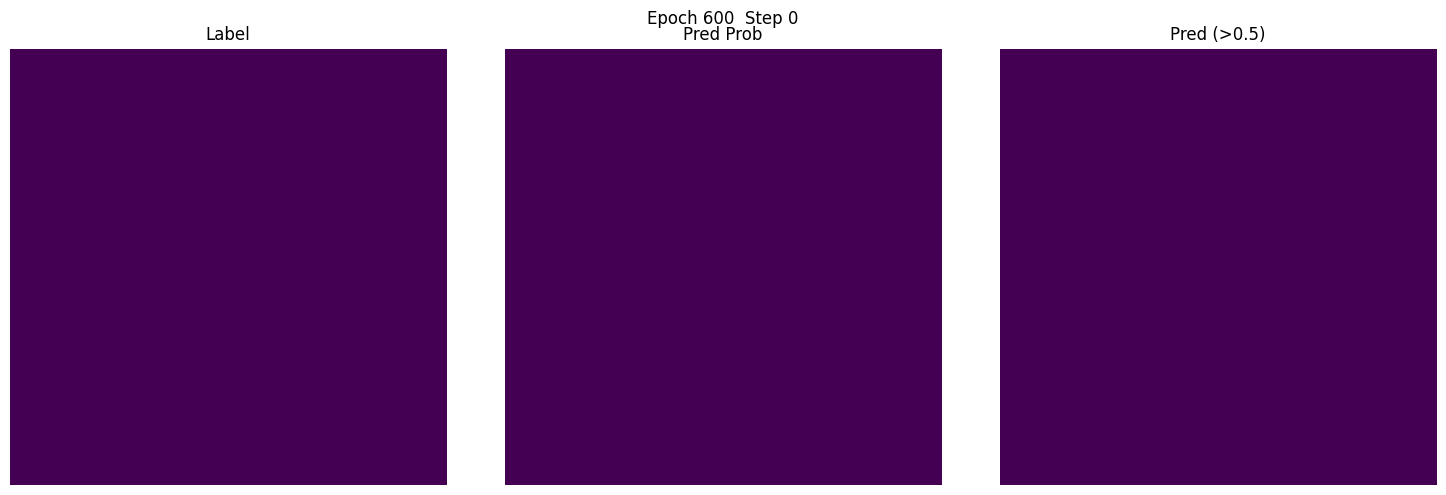

Epoch 650/1000 - loss: 0.0000
lr: 7.405874159523969e-06


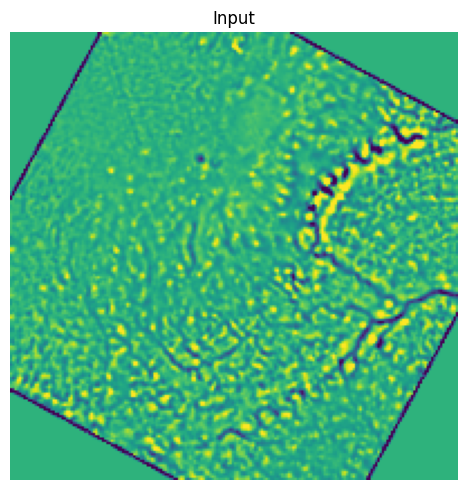

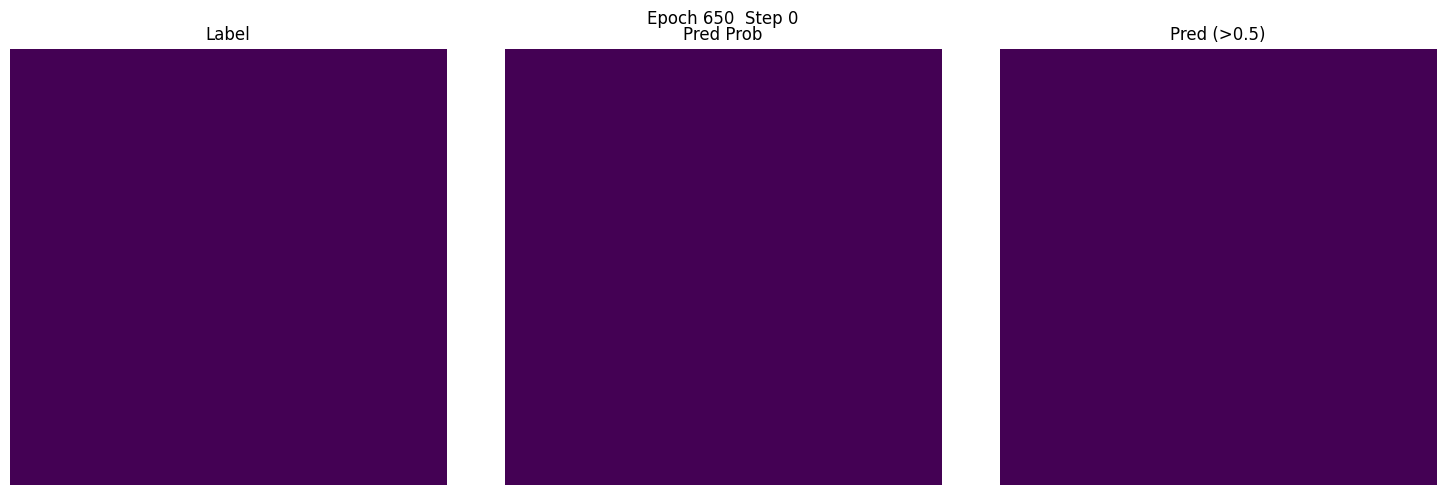

Epoch 700/1000 - loss: 0.0000
lr: 3.7744265859818586e-06


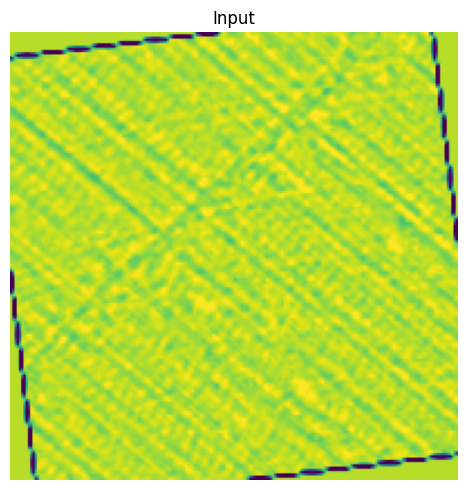

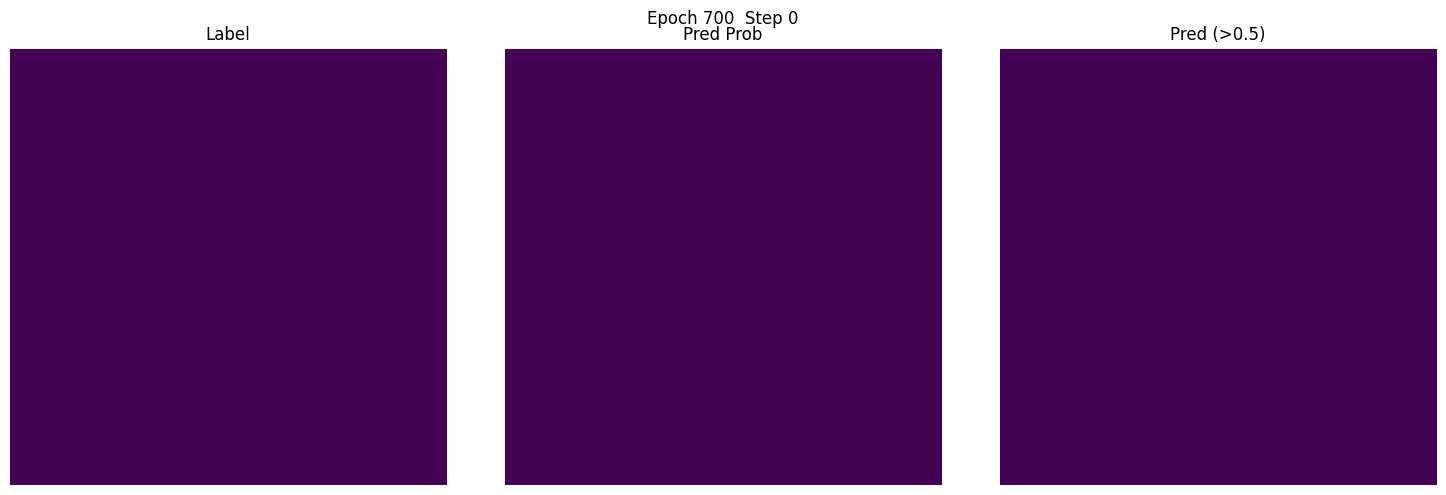

Epoch 750/1000 - loss: 0.0000
lr: 1.829830710932086e-06


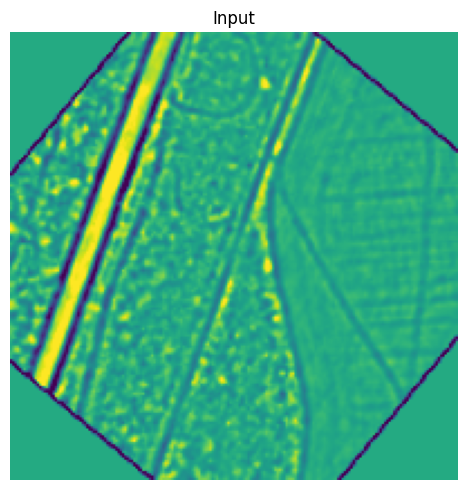

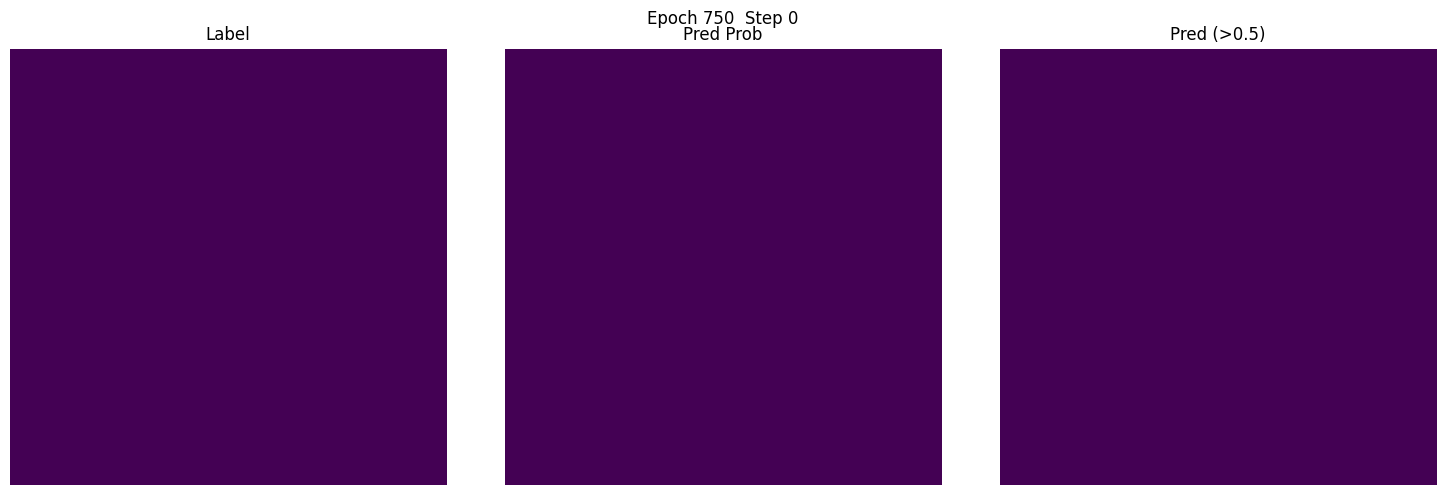

Epoch 800/1000 - loss: 0.0583
lr: 8.438322459067534e-07


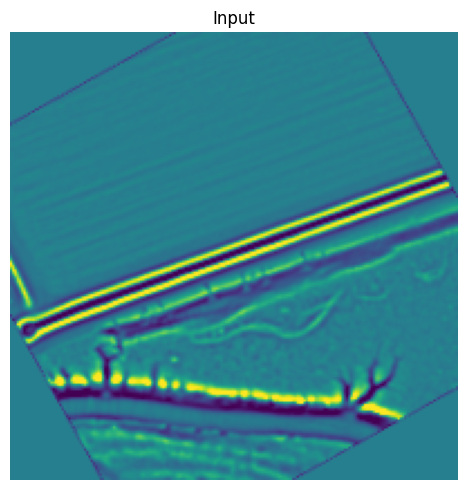

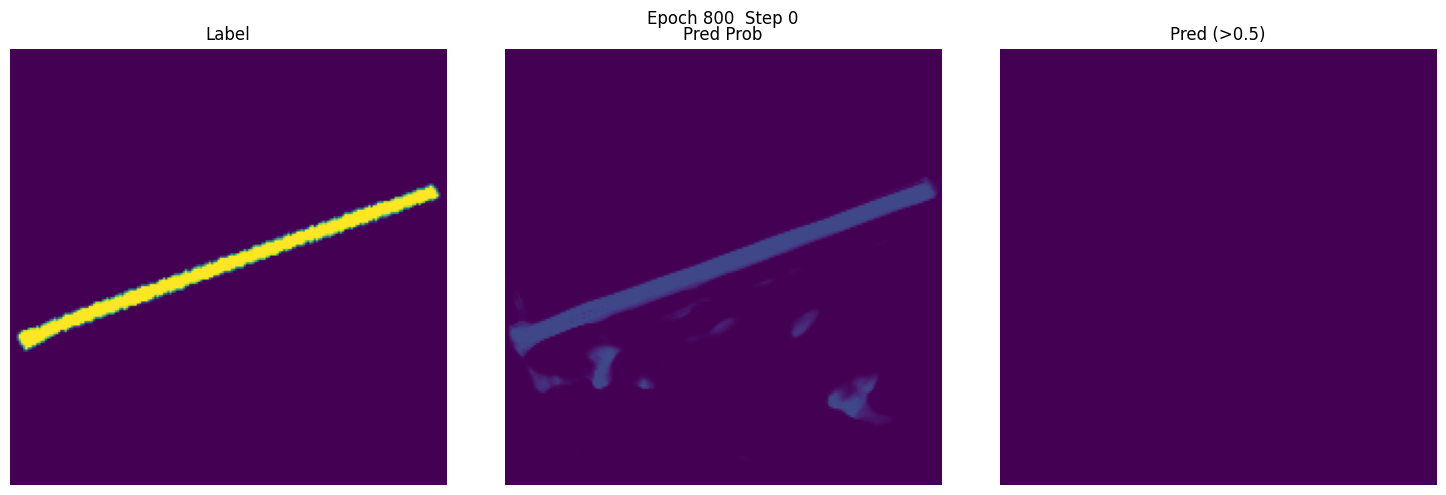

KeyboardInterrupt: 

In [ ]:
# Residual connections (skip connections within block)
#model_residual = train_model(willowan_data,
#                    num_epochs=1000,
#                    viz_every=50,
#                    features=[8,16,32],
#                    lr=5e-4,
#                    lr_decay=0.99999995,
#                    pos_bias=1,
#                    block_config=UNET_BLOCK_RESIDUAL,)


In [ ]:
willowan_data = ModelData()
willowan_data.prepare_data("WILLOWAN", sliding_window_size=200, stride=100)

Epoch 200/2500 - loss: 0.1379
lr: 0.002018798996757834


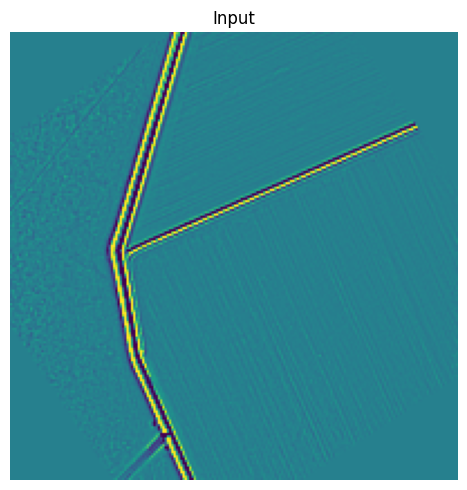

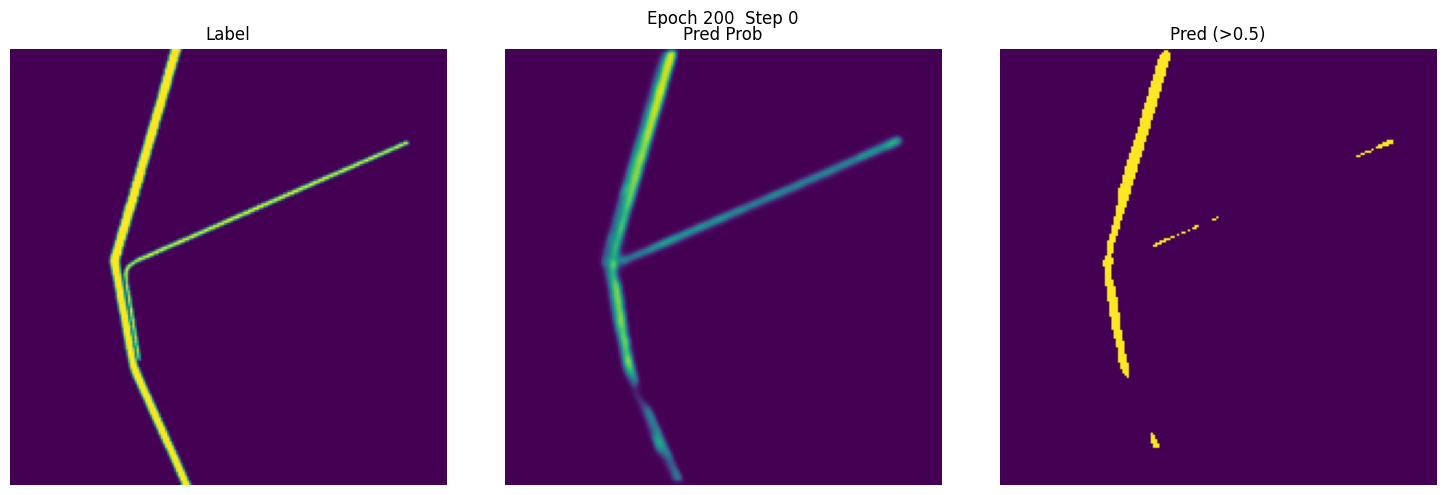

In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=2500,
                    viz_every=200,
                    features=[16,32,64,128,256],
                    lr=3e-3,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999995,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


In [ ]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=300,
                    viz_every=30,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=0.99999999,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)


# UNet Block Configuration Variants

Try different block architectures by passing them to train_model:


In [ ]:
dont run past here

In [ ]:
import torch
model_path ="C:\\Users\\jamed\\Documents\\repos\\terrain_classification_project\\QuickTerrainClassification\\data\\model.pth"

In [ ]:
# Create sample input with same shape as training data
sample_input = torch.randn(1, 1, 1000, 1000).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model_residual.eval()
scripted = torch.jit.trace(model_residual, sample_input)
scripted.save(model_path)